In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay,f1_score, confusion_matrix
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
df = pd.read_csv("data/dataset-tickets-multi-lang-4-20k.csv")

In [3]:
df.head()

,subject,body,answer,type,queue,priority,language,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Unvorhergesehener Absturz der Datenanalyse-Pla...,Die Datenanalyse-Plattform brach unerwartet ab...,Ich werde Ihnen bei der Lösung des Problems he...,Incident,General Inquiry,low,de,Crash,Technical,Bug,Hardware,Resolution,Outage,Documentation,NaN
1,Customer Support Inquiry,Seeking information on digital strategies that...,We offer a variety of digital strategies and s...,Request,Customer Service,medium,en,Feedback,Sales,IT,Tech Support,NaN,NaN,NaN,NaN
2,Data Analytics for Investment,I am contacting you to request information on ...,I am here to assist you with data analytics to...,Request,Customer Service,medium,en,Technical,Product,Guidance,Documentation,Performance,Feature,NaN,NaN
3,Krankenhaus-Dienstleistung-Problem,Ein Medien-Daten-Sperrverhalten trat aufgrund ...,Zurück zur E-Mail-Beschwerde über den Sperrver...,Incident,Customer Service,high,de,Security,Breach,Login,Maintenance,Incident,Resolution,Feedback,NaN
4,Security,"Dear Customer Support, I am reaching out to in...","Dear [name], we take the security of medical d...",Request,Customer Service,medium,en,Security,Customer,Compliance,Breach,Documentation,Guidance,NaN,NaN


In [4]:
df.shape

(20000, 15)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   subject   18539 non-null  object
 1   body      19998 non-null  object
 2   answer    19996 non-null  object
 3   type      20000 non-null  object
 4   queue     20000 non-null  object
 5   priority  20000 non-null  object
 6   language  20000 non-null  object
 7   tag_1     20000 non-null  object
 8   tag_2     19954 non-null  object
 9   tag_3     19905 non-null  object
 10  tag_4     18461 non-null  object
 11  tag_5     13091 non-null  object
 12  tag_6     7351 non-null   object
 13  tag_7     3928 non-null   object
 14  tag_8     1907 non-null   object
dtypes: object(15)
memory usage: 2.3+ MB


In [6]:
df.columns

Index(['subject', 'body', 'answer', 'type', 'queue', 'priority', 'language',
       'tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8'],
      dtype='object')

In [7]:
df.isnull().sum()


subject      1461
body            2
answer          4
type            0
queue           0
priority        0
language        0
tag_1           0
tag_2          46
tag_3          95
tag_4        1539
tag_5        6909
tag_6       12649
tag_7       16072
tag_8       18093
dtype: int64

In [8]:
df["type"].value_counts()

type
Incident    7978
Request     5763
Problem     4184
Change      2075
Name: count, dtype: int64

In [9]:
df['priority'].value_counts()

priority
medium    8144
high      7801
low       4055
Name: count, dtype: int64

In [10]:
df["queue"].value_counts()

queue
Technical Support                  5824
Product Support                    3708
Customer Service                   3152
IT Support                         2292
Billing and Payments               2086
Returns and Exchanges              1001
Service Outages and Maintenance     764
Sales and Pre-Sales                 572
Human Resources                     338
General Inquiry                     263
Name: count, dtype: int64

In [11]:
df['language'].value_counts()

language
en    11923
de     8077
Name: count, dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.dtypes

subject     object
body        object
answer      object
type        object
queue       object
priority    object
language    object
tag_1       object
tag_2       object
tag_3       object
tag_4       object
tag_5       object
tag_6       object
tag_7       object
tag_8       object
dtype: object

In [14]:
df['subject'].isnull().sum()

np.int64(1461)

In [15]:
df["subject"].fillna("").str.len().describe()

count    20000.000000
mean        41.594600
std         21.582385
min          0.000000
25%         31.000000
50%         41.000000
75%         53.000000
max        412.000000
Name: subject, dtype: float64

In [16]:
df["body"].fillna("").str.len().describe()

count    20000.00000
mean       394.43810
std        248.26091
min          0.00000
25%        198.00000
50%        357.00000
75%        555.00000
max       2259.00000
Name: body, dtype: float64

#### Target Distribution

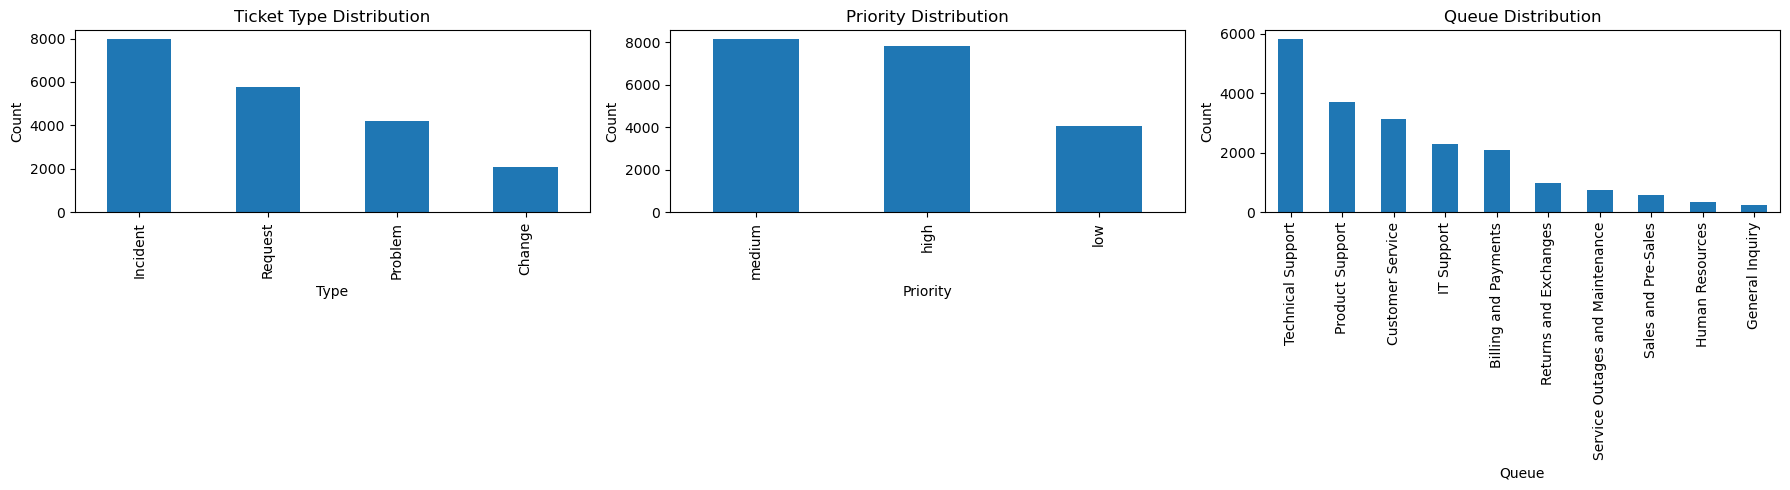

In [17]:
fig, axes = plt.subplots(1,3, figsize=(18,5))

df['type'].value_counts().plot(kind = 'bar', ax = axes[0])
axes[0].set_title("Ticket Type Distribution")
axes[0].set_xlabel("Type")
axes[0].set_ylabel("Count")

df['priority'].value_counts().plot(kind = 'bar', ax = axes[1])
axes[1].set_title("Priority Distribution")
axes[1].set_xlabel("Priority")
axes[1].set_ylabel("Count")

df["queue"].value_counts().plot(kind='bar', ax=axes[2])
axes[2].set_title("Queue Distribution")
axes[2].set_xlabel("Queue")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [18]:
for col in ['type','priority', 'queue']:
    print(f'\n--- {col.upper()}--- ')
    counts = df[col].value_counts()
    percentages = df[col].value_counts(normalize = True) *100

    result = pd.DataFrame({
        "Counts":counts,
        "Percentages":percentages.round(2)
        })
    print(result)


--- TYPE--- 
          Counts  Percentages
type                         
Incident    7978        39.89
Request     5763        28.82
Problem     4184        20.92
Change      2075        10.38

--- PRIORITY--- 
          Counts  Percentages
priority                     
medium      8144        40.72
high        7801        39.01
low         4055        20.28

--- QUEUE--- 
                                 Counts  Percentages
queue                                               
Technical Support                  5824        29.12
Product Support                    3708        18.54
Customer Service                   3152        15.76
IT Support                         2292        11.46
Billing and Payments               2086        10.43
Returns and Exchanges              1001         5.00
Service Outages and Maintenance     764         3.82
Sales and Pre-Sales                 572         2.86
Human Resources                     338         1.69
General Inquiry                     263 

In [19]:
df['text'] = (
    df['subject'].fillna("").astype(str) + " " +
    df['body'].fillna("").astype(str)
).str.strip()
print("Total rows:",len(df))
print("Unique texts:",df['text'].nunique())
print("duplicate texts:",df['text'].duplicated().sum())

Total rows: 20000
Unique texts: 20000
duplicate texts: 0


In [20]:
duplicated_text = df[df['text'].duplicated(keep=False)].sort_values('text')
print(duplicated_text[["text", "type", "queue", "priority"]].head(20))

Empty DataFrame
Columns: [text, type, queue, priority]
Index: []


In [21]:
for target in ["type", "queue", "priority"]:
    conflicts = (
        df.groupby("text")[target]
        .nunique()
        .gt(1)
        .sum()
    )
    
    print(f"{target}: {conflicts} texts have conflicting labels")

type: 0 texts have conflicting labels
queue: 0 texts have conflicting labels
priority: 0 texts have conflicting labels


## Queue Prediction

In [22]:
model_df = df[["text", "queue", "priority", "type"]].copy()

In [23]:
model_df = model_df[model_df['text'].str.strip()!=""]

In [24]:
print("shape:", model_df.shape)
print(model_df.head())

shape: (20000, 4)
                                                text             queue  \
0  Unvorhergesehener Absturz der Datenanalyse-Pla...   General Inquiry   
1  Customer Support Inquiry Seeking information o...  Customer Service   
2  Data Analytics for Investment I am contacting ...  Customer Service   
3  Krankenhaus-Dienstleistung-Problem Ein Medien-...  Customer Service   
4  Security Dear Customer Support, I am reaching ...  Customer Service   

  priority      type  
0      low  Incident  
1   medium   Request  
2   medium   Request  
3     high  Incident  
4   medium   Request  


In [25]:
X = model_df['text']
y = model_df['queue']

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify = y
)

Why stratify=y?

Our queue classes are imbalanced.

stratify=y tries to preserve approximately the same class proportions in both training and testing sets.

In [27]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 16000
Testing samples: 4000


In [28]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [29]:
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [30]:
print("Training shape:", X_train_tfidf.shape)
print("Testing shape:", X_test_tfidf.shape)

Training shape: (16000, 70227)
Testing shape: (4000, 70227)


In [31]:
print("Number of features:", len(tfidf.get_feature_names_out()))

Number of features: 70227


In [32]:
print(tfidf.get_feature_names_out()[:50])

['00' '00 uhr' '04' '04 lts' '06' '06 processing' '10' '10 attempted'
 '10 buster' '10 pro' '10 project' '10 various' '11' '11 application'
 '11 digital' '11 macbook' '11 saas' '11 suite' '11 zu' '12' '12 software'
 '12 user' '13' '13 attempted' '13 data' '13 database' '13 debian'
 '13 enhanced' '13 environment' '13 für' '13 hospital' '13 ich'
 '13 integration' '13 jira' '13 logs' '13 provide' '13 saas' '13 scalable'
 '13 sehr' '13 systems' '13 thank' '13 und' '14' '14 17' '14 saas'
 '14 thank' '15' '15 agency' '15 attempted' '15 sehr']


In [33]:
model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [34]:
model.fit(X_train_tfidf, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [35]:
y_pred = model.predict(X_test_tfidf)

In [36]:
print(y_pred[:20])

['Product Support' 'Product Support' 'Product Support' 'Technical Support'
 'Service Outages and Maintenance' 'Customer Service' 'Product Support'
 'General Inquiry' 'IT Support' 'Customer Service' 'Product Support'
 'Technical Support' 'Technical Support' 'IT Support'
 'Returns and Exchanges' 'Technical Support' 'Technical Support'
 'Billing and Payments' 'Technical Support' 'Human Resources']


In [37]:
accuracy = accuracy_score(y_test, y_pred)

In [38]:
print("Accuracy:", round(accuracy, 4))
print("\n Classification Reprot: \n")
print(classification_report(y_test, y_pred))

Accuracy: 0.435

 Classification Reprot: 

                                 precision    recall  f1-score   support

           Billing and Payments       0.68      0.73      0.70       417
               Customer Service       0.36      0.36      0.36       630
                General Inquiry       0.25      0.36      0.29        53
                Human Resources       0.46      0.47      0.46        68
                     IT Support       0.38      0.41      0.40       458
                Product Support       0.41      0.31      0.35       742
          Returns and Exchanges       0.26      0.36      0.30       200
            Sales and Pre-Sales       0.23      0.46      0.30       114
Service Outages and Maintenance       0.41      0.61      0.49       153
              Technical Support       0.53      0.44      0.48      1165

                       accuracy                           0.43      4000
                      macro avg       0.40      0.45      0.42      4000
      

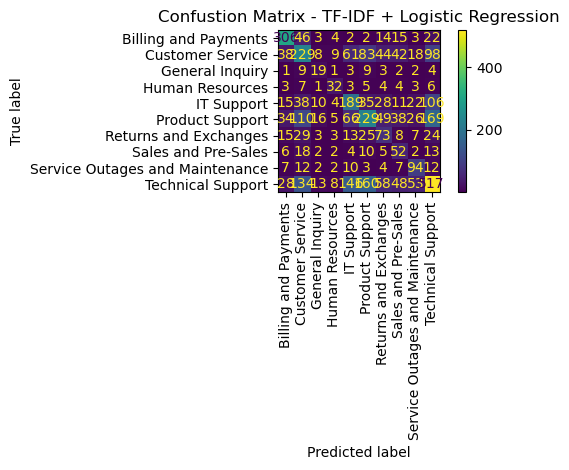

In [39]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, xticks_rotation=90)
plt.title("Confustion Matrix - TF-IDF + Logistic Regression")
plt.tight_layout()
plt.show()

In [40]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
cm_df = pd.DataFrame(cm, index=model.classes_, columns = model.classes_)
print(cm_df)

                                 Billing and Payments  Customer Service  \
Billing and Payments                              306                46   
Customer Service                                   38               229   
General Inquiry                                     1                 9   
Human Resources                                     3                 7   
IT Support                                         15                38   
Product Support                                    34               110   
Returns and Exchanges                              15                29   
Sales and Pre-Sales                                 6                18   
Service Outages and Maintenance                     7                12   
Technical Support                                  28               134   

                                 General Inquiry  Human Resources  IT Support  \
Billing and Payments                           3                4           2   
Customer Ser

In [41]:
svm_model = LinearSVC(
    class_weight="balanced",
    random_state=42
)

In [42]:
svm_model.fit(X_train_tfidf, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [43]:
y_pred_svm = svm_model.predict(X_test_tfidf)

In [44]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("SVM Accuracy:", round(accuracy_svm, 4))
print("\nSVM Classification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.5305

SVM Classification Report:

                                 precision    recall  f1-score   support

           Billing and Payments       0.73      0.79      0.76       417
               Customer Service       0.47      0.48      0.48       630
                General Inquiry       0.53      0.36      0.43        53
                Human Resources       0.57      0.50      0.53        68
                     IT Support       0.47      0.47      0.47       458
                Product Support       0.48      0.43      0.46       742
          Returns and Exchanges       0.42      0.39      0.40       200
            Sales and Pre-Sales       0.40      0.48      0.44       114
Service Outages and Maintenance       0.56      0.60      0.58       153
              Technical Support       0.56      0.58      0.57      1165

                       accuracy                           0.53      4000
                      macro avg       0.52      0.51      0.51      4000

In [45]:

logistic_macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro"
)

svm_macro_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="macro"
)

print("Logistic Regression Macro F1:", round(logistic_macro_f1, 4))
print("Linear SVM Macro F1:", round(svm_macro_f1, 4))

Logistic Regression Macro F1: 0.4153
Linear SVM Macro F1: 0.5111


#### Error Analysis of SVM

In [46]:
cm_svm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=svm_model.classes_
)

In [47]:
cm_svm_df = pd.DataFrame(
    cm_svm,
    index=svm_model.classes_,
    columns=svm_model.classes_
)

In [48]:
print(cm_svm_df)

                                 Billing and Payments  Customer Service  \
Billing and Payments                              329                32   
Customer Service                                   29               302   
General Inquiry                                     1                 8   
Human Resources                                     4                 6   
IT Support                                         14                38   
Product Support                                    25                92   
Returns and Exchanges                              10                25   
Sales and Pre-Sales                                 8                17   
Service Outages and Maintenance                     3                10   
Technical Support                                  29               111   

                                 General Inquiry  Human Resources  IT Support  \
Billing and Payments                           0                1           6   
Customer Ser

In [49]:
errors = []
for actual in svm_model.classes_:
    for predicted in svm_model.classes_:
        if actual != predicted:
            count = cm_svm_df.loc[actual, predicted]

            if count>0:
                errors.append((actual, predicted, count))

errors_df = pd.DataFrame(
    errors,
    columns = ['Actual', 'Predicted', 'Count']
).sort_values("Count", ascending=False)


In [50]:
print(errors_df.head(15))

                   Actual            Predicted  Count
50        Product Support    Technical Support    186
81      Technical Support      Product Support    137
41             IT Support    Technical Support    121
16       Customer Service    Technical Support    120
77      Technical Support     Customer Service    111
80      Technical Support           IT Support    109
43        Product Support     Customer Service     92
12       Customer Service      Product Support     81
46        Product Support           IT Support     48
37             IT Support      Product Support     43
11       Customer Service           IT Support     42
34             IT Support     Customer Service     38
59  Returns and Exchanges    Technical Support     33
0    Billing and Payments     Customer Service     32
83      Technical Support  Sales and Pre-Sales     32


In [51]:
embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

multilingual → suitable for our English + German data.
paraphrase → trained to recognize similar meanings even when wording is different.
MiniLM → relatively small and fast compared with much larger transformer models.
L12 → it has 12 transformer layers.
v2 → the particular version of that model.

In [52]:
print(embedding_model)

SentenceTransformer(
  (0): Transformer({'transformer_task': 'feature-extraction', 'modality_config': {'text': {'method': 'forward', 'method_output_name': 'last_hidden_state'}}, 'module_output_name': 'token_embeddings', 'architecture': 'BertModel'})
  (1): Pooling({'embedding_dimension': 384, 'pooling_mode': 'mean', 'include_prompt': True})
)


### Generate Embeddings

In [53]:
X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    batch_size = 32,
    show_progress_bar=True
)

Batches:   0%|          | 0/500 [00:00<?, ?it/s]

In [54]:
X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/125 [00:00<?, ?it/s]

In [55]:
print(X_train_embeddings.shape)
print(X_test_embeddings.shape)

(16000, 384)
(4000, 384)


### SVM + Sentence Embedding

In [56]:
embedding_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

In [57]:
embedding_svm.fit(X_train_embeddings,y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [58]:
y_pred_embedding = embedding_svm.predict(X_test_embeddings)

In [59]:
accuracy_embedding = accuracy_score(
    y_test,
    y_pred_embedding
)

In [60]:
print("Embedding + SVM Accuracy:", round(accuracy_embedding,4))

Embedding + SVM Accuracy: 0.3118


In [61]:
print(classification_report(y_test, y_pred_embedding))

                                 precision    recall  f1-score   support

           Billing and Payments       0.65      0.73      0.69       417
               Customer Service       0.33      0.21      0.26       630
                General Inquiry       0.06      0.40      0.10        53
                Human Resources       0.11      0.56      0.19        68
                     IT Support       0.26      0.18      0.22       458
                Product Support       0.37      0.16      0.22       742
          Returns and Exchanges       0.14      0.20      0.17       200
            Sales and Pre-Sales       0.13      0.39      0.20       114
Service Outages and Maintenance       0.22      0.53      0.31       153
              Technical Support       0.48      0.33      0.39      1165

                       accuracy                           0.31      4000
                      macro avg       0.28      0.37      0.27      4000
                   weighted avg       0.38      0

In [62]:
tfidf_multi = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [63]:
X_train_tfidf_multi = tfidf_multi.fit_transform(X_train)
X_test_tfidf_multi = tfidf_multi.transform(X_test)

In [64]:
svm_multi = LinearSVC(
    class_weight="balanced",
    random_state=42
)

In [65]:
svm_multi.fit(X_train_tfidf_multi, y_train)

LinearSVC(class_weight='balanced', random_state=42)

In [66]:
y_pred_svm_multi = svm_multi.predict(X_test_tfidf_multi)

In [67]:
print(classification_report(y_test, y_pred_svm_multi))

                                 precision    recall  f1-score   support

           Billing and Payments       0.73      0.79      0.76       417
               Customer Service       0.46      0.47      0.47       630
                General Inquiry       0.46      0.36      0.40        53
                Human Resources       0.59      0.49      0.53        68
                     IT Support       0.45      0.46      0.46       458
                Product Support       0.49      0.44      0.46       742
          Returns and Exchanges       0.44      0.40      0.41       200
            Sales and Pre-Sales       0.45      0.54      0.49       114
Service Outages and Maintenance       0.53      0.56      0.54       153
              Technical Support       0.56      0.57      0.56      1165

                       accuracy                           0.53      4000
                      macro avg       0.52      0.51      0.51      4000
                   weighted avg       0.52      0

In [68]:
enumerate(svm_multi.classes_)

In [69]:
feature_names = tfidf_multi.get_feature_names_out()

In [70]:
for i, class_name in enumerate(svm_multi.classes_):
    top_indices = np.argsort(svm_multi.coef_[i])[-15:][::-1]

    print(f"\n{class_name}")
    print(", ".join(feature_names[top_indices]))


Billing and Payments
billing, payment, invoice, rechnung, invoices, rechnungen, pricing, rechnungsstellung, abonnements, charges, joystick, gebühren, account, kontoeinstellungen, kosten

Customer Service
offer data, applications are, your project, digital presence, to generate, ai financial, und ressourcen, analysis software, optimization could, features and, datensicherheitslösungen, analytics services, mysql for, update or, development

General Inquiry
technology, erhöhte sicherheit, or steps, smart devices, analytics is, information need, campaigns insufficient, analysetools verbessern, need assistance, digital methods, difficulties following, tactics is, tech products, this integration, solutions is

Human Resources
employee, hr, training, mitarbeiter, breach detected, an employee, update data, gaming products, expansion which, aws, pytorch, variations in, data compromise, possible data, discord and

IT Support
github, software the, settings for, laptop, website, load and, in proj

## Priority Prediction

In [71]:
X = model_df['text']
y = model_df['priority']

In [72]:
X_train_priority, X_test_priority, y_train_priority, y_test_priority = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [73]:
print("Training samples:", len(X_train_priority))
print("Testing samples:", len(X_test_priority))

print("\nTraining distribution:")
print(y_train_priority.value_counts(normalize=True).round(3))

print("\nTesting distribution:")
print(y_test_priority.value_counts(normalize=True).round(3))

Training samples: 16000
Testing samples: 4000

Training distribution:
priority
medium    0.407
high      0.390
low       0.203
Name: proportion, dtype: float64

Testing distribution:
priority
medium    0.407
high      0.390
low       0.203
Name: proportion, dtype: float64


In [74]:
priority_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [75]:
X_train_priority_tfidf = priority_tfidf.fit_transform(X_train_priority)
X_test_priority_tfidf = priority_tfidf.transform(X_test_priority)

In [76]:
print("Training TF-IDF shape:", X_train_priority_tfidf.shape)
print("Testing TF-IDF shape:", X_test_priority_tfidf.shape)

Training TF-IDF shape: (16000, 71842)
Testing TF-IDF shape: (4000, 71842)


In [77]:
priority_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [78]:
priority_lr.fit(X_train_priority_tfidf, y_train_priority)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [79]:
y_pred_priority_lr = priority_lr.predict(X_test_priority_tfidf)

In [80]:
print(classification_report(y_test_priority, y_pred_priority_lr))

              precision    recall  f1-score   support

        high       0.59      0.58      0.59      1560
         low       0.44      0.50      0.47       811
      medium       0.56      0.53      0.55      1629

    accuracy                           0.55      4000
   macro avg       0.53      0.54      0.53      4000
weighted avg       0.55      0.55      0.55      4000



In [81]:
cm_priority_lr = confusion_matrix(y_test_priority, y_pred_priority_lr,labels=priority_lr.classes_)

In [82]:
disp = ConfusionMatrixDisplay(
    confusion_matrix= cm_priority_lr,
    display_labels=priority_lr.classes_
)

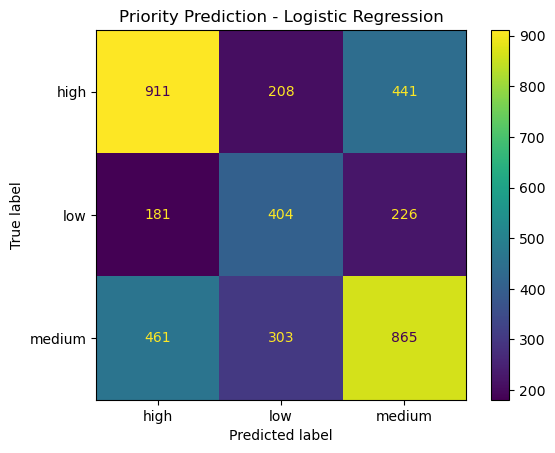

In [83]:
disp.plot()
plt.title("Priority Prediction - Logistic Regression")
plt.show()

In [84]:
priority_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

In [85]:
priority_svm.fit(X_train_priority_tfidf,y_train_priority)

LinearSVC(class_weight='balanced', random_state=42)

In [86]:
y_pred_priority_svm = priority_svm.predict(X_test_priority_tfidf)

In [87]:
print(classification_report(y_test_priority, y_pred_priority_svm))

              precision    recall  f1-score   support

        high       0.60      0.64      0.61      1560
         low       0.51      0.44      0.47       811
      medium       0.58      0.59      0.58      1629

    accuracy                           0.58      4000
   macro avg       0.56      0.55      0.56      4000
weighted avg       0.57      0.58      0.57      4000



In [88]:
cm_priority_svm = confusion_matrix(
    y_test_priority,
    y_pred_priority_svm,
    labels=priority_svm.classes_
)

In [89]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_priority_svm,
    display_labels=priority_svm.classes_
)

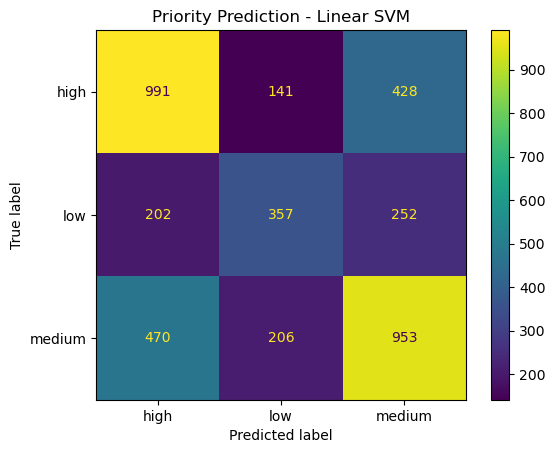

In [90]:
disp.plot()
plt.title("Priority Prediction - Linear SVM")
plt.show()

In [91]:
print("Priority classes:")
print(priority_svm.classes_)

print("\nConfusion Matrix:")
print(cm_priority_svm)

Priority classes:
['high' 'low' 'medium']

Confusion Matrix:
[[991 141 428]
 [202 357 252]
 [470 206 953]]


In [92]:
feature_names_priority = priority_tfidf.get_feature_names_out()

In [93]:
for i, class_name in enumerate(priority_svm.classes_):
    top_indices = np.argsort(priority_svm.coef_[i])[-20:][::-1]

    print(f"\n{class_name.upper()}")
    print(",".join(feature_names_priority[top_indices]))


HIGH
crashes,outlook 2021,sensitive medical,the servers,systemausfall,hospital settings,logs,crashed,data breach,me through,management and,system crash,optimization platform,for integrating,incident medical,access event,software crashes,the error,billing services,commerce

LOW
strategies are,terraform,this is,dashboard loading,for financial,difficulties in,marketing team,keras,system logs,adjust,task synchronization,features can,on our,welche digitalen,configuration errors,access system,media engagement,the initial,analysis dashboards,analytics report

MEDIUM
solutions for,in healthcare,inaccuracy,schoology,intermittent,management dashboard,appreciate guidance,rechnungen,not working,with sql,conflicts with,information would,update security,and improve,the server,agency has,an error,tracking,indexing,trends


## Type Prediction

In [94]:
X = model_df["text"]
y = model_df["type"]

In [95]:
X_train_type, X_test_type, y_train_type, y_test_type = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [96]:
print("Training Samples:", len(X_train_type))
print("Testing Samples:", len(X_test_type))

Training Samples: 16000
Testing Samples: 4000


In [97]:
print("\n Training Distribution:")
print(y_train_type.value_counts(normalize=True).round(3))

print("\n Testing Dsitribution:")
print(y_test_type.value_counts(normalize=True).round(3))


 Training Distribution:
type
Incident    0.399
Request     0.288
Problem     0.209
Change      0.104
Name: proportion, dtype: float64

 Testing Dsitribution:
type
Incident    0.399
Request     0.288
Problem     0.209
Change      0.104
Name: proportion, dtype: float64


In [98]:
type_tfidf = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1,2),
    min_df=2,
    max_df=0.95
)

In [99]:
X_train_type_tfidf = type_tfidf.fit_transform(X_train_type)
X_test_type_tfidf = type_tfidf.transform(X_test_type)

In [100]:
print("Training TF-IDF Shape: ", X_train_type_tfidf.shape)
print("Testing TF-IDF Shape:", X_test_type_tfidf.shape)

Training TF-IDF Shape:  (16000, 71729)
Testing TF-IDF Shape: (4000, 71729)


In [101]:
type_lr = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

In [102]:
type_lr.fit(X_train_type_tfidf, y_train_type)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [103]:
y_pred_type_lr = type_lr.predict(X_test_type_tfidf)

In [104]:
print(classification_report(y_test_type, y_pred_type_lr))

              precision    recall  f1-score   support

      Change       0.93      0.93      0.93       415
    Incident       0.79      0.72      0.76      1596
     Problem       0.55      0.63      0.59       837
     Request       0.97      0.98      0.97      1152

    accuracy                           0.80      4000
   macro avg       0.81      0.82      0.81      4000
weighted avg       0.81      0.80      0.80      4000



In [105]:
cm_type_lr = confusion_matrix(
    y_test_type,
    y_pred_type_lr,
    labels=type_lr.classes_
)

In [106]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_type_lr,
    display_labels=type_lr.classes_
)

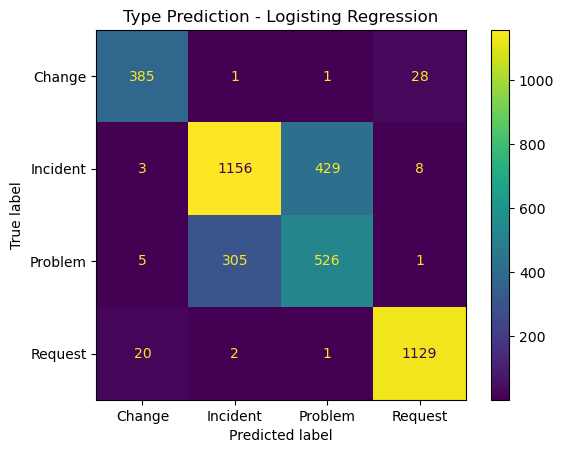

In [107]:
disp.plot()
plt.title("Type Prediction - Logisting Regression")
plt.show()

In [108]:
type_svm = LinearSVC(
    class_weight="balanced",
    random_state=42
)

In [109]:
type_svm.fit(X_train_type_tfidf, y_train_type)

LinearSVC(class_weight='balanced', random_state=42)

In [110]:
y_pred_type_svm = type_svm.predict(X_test_type_tfidf)

In [111]:
print(classification_report(y_test_type, y_pred_type_svm))

              precision    recall  f1-score   support

      Change       0.97      0.92      0.94       415
    Incident       0.78      0.83      0.81      1596
     Problem       0.64      0.56      0.60       837
     Request       0.97      0.99      0.98      1152

    accuracy                           0.83      4000
   macro avg       0.84      0.82      0.83      4000
weighted avg       0.82      0.83      0.83      4000



In [112]:
print("Type classes:")
print(type_lr.classes_)

print("\nConfusion Matrix:")
print(cm_type_lr)

Type classes:
['Change' 'Incident' 'Problem' 'Request']

Confusion Matrix:
[[ 385    1    1   28]
 [   3 1156  429    8]
 [   5  305  526    1]
 [  20    2    1 1129]]


In [113]:
cm_type_svm = confusion_matrix(
    y_test_type,
    y_pred_type_svm,
    labels=type_svm.classes_
)

In [114]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_type_svm,
    display_labels=type_svm.classes_
)

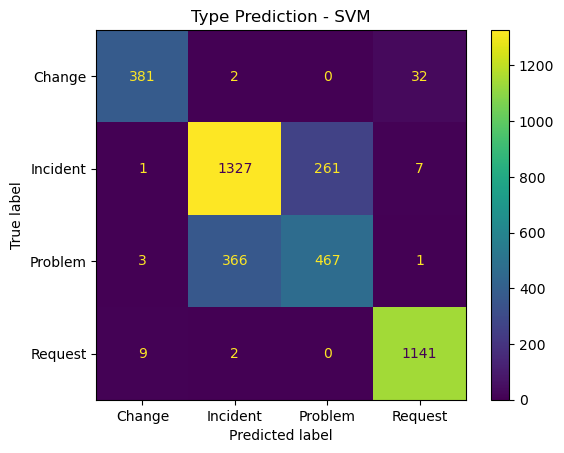

In [115]:
disp.plot()
plt.title("Type Prediction - SVM")
plt.show()

In [116]:
print("Type classes:")
print(type_svm.classes_)

print("\nConfusion Matrix:")
print(cm_type_svm)

Type classes:
['Change' 'Incident' 'Problem' 'Request']

Confusion Matrix:
[[ 381    2    0   32]
 [   1 1327  261    7]
 [   3  366  467    1]
 [   9    2    0 1141]]


In [117]:
type_decision_scores = type_svm.decision_function(
    X_test_type_tfidf
)

print("Decision score shape:", type_decision_scores.shape)

Decision score shape: (4000, 4)


In [118]:
def predict_ticket(subject,body):

    # combine subject and body
    text = f"{subject} {body}".strip()

    # queue prediction
    queue_vector = tfidf_multi.transform([text])
    queue_prediction = svm_multi.predict(queue_vector)[0]

    #Priority prediction
    priority_vector = priority_tfidf.transform([text])
    priority_prediction = priority_svm.predict(priority_vector)[0]

    # Type prediction
    type_vector = type_tfidf.transform([text])
    type_predection = type_svm.predict(type_vector)[0]\

    return {
        "Queue" : queue_prediction,
        "Priority": priority_prediction,
        "Type": type_predection
    }

## Testing 

In [119]:
result = predict_ticket(
    subject="Application is completely down",
    body="Users are unable to access the application after the latest update. The service is currently unavailable."
)

print(result)

{'Queue': 'Technical Support', 'Priority': 'high', 'Type': 'Problem'}


In [120]:
def predict_ticket_with_scores(subject,body):

    # combine subject and body
    text = f"{subject} {body}".strip()

    # queue prediction
    queue_vector = tfidf_multi.transform([text])
    queue_prediction = svm_multi.predict(queue_vector)[0]
    queue_scores = svm_multi.decision_function(queue_vector)[0]

    #Priority prediction
    priority_vector = priority_tfidf.transform([text])
    priority_prediction = priority_svm.predict(priority_vector)[0]
    priority_scores = priority_svm.decision_function(priority_vector)[0]

    # Type prediction
    type_vector = type_tfidf.transform([text])
    type_predection = type_svm.predict(type_vector)[0]
    type_score = type_svm.decision_function(type_vector)[0]

    return {
        "Queue" : queue_prediction,
        "Priority": priority_prediction,
        "Type": type_predection,
        "Queue Scores" : dict(zip(svm_multi.classes_, queue_scores)),
        "Priority Scores" : dict(zip(priority_svm.classes_, priority_scores)),
        "Type Scores" : dict(zip(type_svm.classes_, type_score))
    }

In [121]:
result = predict_ticket_with_scores(
    subject="Application is completely down",
    body="Users are unable to access the application after the latest update. The service is currently unavailable."
)

for key, value in result.items():
    print(f"\n{key}:")
    print(value)


Queue:
Technical Support

Priority:
high

Type:
Problem

Queue Scores:
{'Billing and Payments': np.float64(-0.6317013721056627), 'Customer Service': np.float64(-1.0850120962701881), 'General Inquiry': np.float64(-1.2110602605678504), 'Human Resources': np.float64(-1.3759781052435107), 'IT Support': np.float64(-0.7038767704118015), 'Product Support': np.float64(-0.9755226387887752), 'Returns and Exchanges': np.float64(-1.1575284553123224), 'Sales and Pre-Sales': np.float64(-0.9593851104604486), 'Service Outages and Maintenance': np.float64(-0.5244695575100089), 'Technical Support': np.float64(-0.47666817862856964)}

Priority Scores:
{'high': np.float64(0.34262920615783876), 'low': np.float64(-1.0200178488563105), 'medium': np.float64(-0.5191512465662796)}

Type Scores:
{'Change': np.float64(-0.6929483029738417), 'Incident': np.float64(-0.23269840374493583), 'Problem': np.float64(-0.032251036267091915), 'Request': np.float64(-1.3489368375367006)}


In [122]:
def get_prediction_margin(model, vector):
    
    scores = model.decision_function(vector)
    
    scores = scores[0]
    
    sorted_scores = np.sort(scores)[::-1]
    
    top_score = sorted_scores[0]
    second_score = sorted_scores[1]
    
    margin = top_score - second_score
    
    return top_score, second_score, margin

In [123]:
text = (
    "Application is completely down "
    "Users are unable to access the application after the latest update. "
    "The service is currently unavailable."
)

# Queue vector
queue_vector = tfidf_multi.transform([text])

# Priority vector
priority_vector = priority_tfidf.transform([text])

# Type vector
type_vector = type_tfidf.transform([text])

In [124]:
# Queue margin
queue_top, queue_second, queue_margin = get_prediction_margin(
    svm_multi,
    queue_vector
)

# Priority margin
priority_top, priority_second, priority_margin = get_prediction_margin(
    priority_svm,
    priority_vector
)

# Type margin
type_top, type_second, type_margin = get_prediction_margin(
    type_svm,
    type_vector
)

print("Queue margin:", queue_margin)
print("Priority margin:", priority_margin)
print("Type margin:", type_margin)

Queue margin: 0.04780137888143926
Priority margin: 0.8617804527241184
Type margin: 0.20044736747784392


In [125]:
def calculate_margin(model, X):
    scores = model.decision_function(X)

    # Handle binary classification just in case
    if scores.ndim == 1:
        margins = np.abs(scores)
    else:
        sorted_scores = np.sort(scores, axis=1)[:, ::-1]
        margins = sorted_scores[:,0] - sorted_scores[:,1]

    return margins

In [126]:
queue_margins = calculate_margin(svm_multi, X_test_tfidf_multi)

In [127]:
priority_margins = calculate_margin(priority_svm, X_test_priority_tfidf)

In [128]:
type_margins = calculate_margin(type_svm, X_test_type_tfidf)

In [129]:
queue_correct = (y_pred_svm_multi == y_test).astype(int)

priority_correct = (y_pred_priority_svm == y_test_priority).astype(int)

type_correct = (y_pred_type_svm == y_test_type).astype(int)

In [130]:
def analyze_confidence(margins, correct):
    results = pd.DataFrame({
        "Margin": margins,
        "Correct": correct
    })

    results["Confidence_Band"] = pd.cut(
        results["Margin"],
        bins=[-np.inf, 0.1, 0.2, 0.4, 0.6, np.inf],
        labels=[
            "Very Low",
            "Low",
            "Medium",
            "High",
            "Very High"
        ]
    )

    summary = results.groupby(
        "Confidence_Band",
        observed=False
    ).agg(
        Tickets=("Correct", "count"),
        Accuracy=("Correct", "mean")
    )

    summary["Accuracy"] = summary["Accuracy"] * 100

    return summary

In [131]:
print("QUEUE CONFIDENCE")
print(analyze_confidence(queue_margins, queue_correct))

print("\nPRIORITY CONFIDENCE")
print(analyze_confidence(priority_margins, priority_correct))

print("\nTYPE CONFIDENCE")
print(analyze_confidence(type_margins, type_correct))

QUEUE CONFIDENCE
                 Tickets   Accuracy
Confidence_Band                    
Very Low             887  31.228861
Low                  693  37.085137
Medium               959  48.592284
High                 552  60.507246
Very High            909  84.928493

PRIORITY CONFIDENCE
                 Tickets   Accuracy
Confidence_Band                    
Very Low             529  40.264650
Low                  474  42.405063
Medium               797  51.442911
High                 677  56.425406
Very High           1523  71.897571

TYPE CONFIDENCE
                 Tickets   Accuracy
Confidence_Band                    
Very Low             193  50.259067
Low                  200  52.000000
Medium               369  66.124661
High                 340  70.588235
Very High           2898  90.786749


In [132]:
def show_top_features(model, vectorizer, top_n=15):

    feature_names = vectorizer.get_feature_names_out()

    for i, class_name in enumerate(model.classes_):

        top_indices = np.argsort(model.coef_[i])[-top_n:][::-1]

        print(f"\n{class_name}")
        print(", ".join(feature_names[top_indices]))

In [133]:
show_top_features(svm_multi, tfidf_multi)


Billing and Payments
billing, payment, invoice, rechnung, invoices, rechnungen, pricing, rechnungsstellung, abonnements, charges, joystick, gebühren, account, kontoeinstellungen, kosten

Customer Service
offer data, applications are, your project, digital presence, to generate, ai financial, und ressourcen, analysis software, optimization could, features and, datensicherheitslösungen, analytics services, mysql for, update or, development

General Inquiry
technology, erhöhte sicherheit, or steps, smart devices, analytics is, information need, campaigns insufficient, analysetools verbessern, need assistance, digital methods, difficulties following, tactics is, tech products, this integration, solutions is

Human Resources
employee, hr, training, mitarbeiter, breach detected, an employee, update data, gaming products, expansion which, aws, pytorch, variations in, data compromise, possible data, discord and

IT Support
github, software the, settings for, laptop, website, load and, in proj

In [134]:
show_top_features(priority_svm, priority_tfidf)


high
crashes, outlook 2021, sensitive medical, the servers, systemausfall, hospital settings, logs, crashed, data breach, me through, management and, system crash, optimization platform, for integrating, incident medical

low
strategies are, terraform, this is, dashboard loading, for financial, difficulties in, marketing team, keras, system logs, adjust, task synchronization, features can, on our, welche digitalen, configuration errors

medium
solutions for, in healthcare, inaccuracy, schoology, intermittent, management dashboard, appreciate guidance, rechnungen, not working, with sql, conflicts with, information would, update security, and improve, the server


In [135]:
show_top_features(type_svm, type_tfidf)


Change
update, verbessern, enhance, aktualisierung, improve, and, enhanced, request, boost, current, encryption, verbesserte, improved, implementierung, erweiterte

Incident
incident, has, vorfall, issues the, system, report, appears, git, response times, lost, malfunction, affected, encountered issues, encryption there, event

Problem
facing, trotz, campagnen, invoicing, elasticsearch cluster, rechnung, records access, post, recurring, duplicate, be an, breaches, perl, updated, to medical

Request
welche, für, for, details, on, strategies, could you, zur, enhancing investment, you, saas, can, von, informationen, could


### Embeddings For Complete Dataset

In [137]:
embedding_model = SentenceTransformer(
    "paraphrase-multilingual-MiniLM-L12-v2"
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [138]:
all_embeddings = embedding_model.encode(
    model_df["text"].tolist(),
    batch_size=32,
    show_progress_bar=True
)

Batches:   0%|          | 0/625 [00:00<?, ?it/s]

In [139]:
print(all_embeddings.shape)

(20000, 384)


In [140]:
from sklearn.preprocessing import normalize

In [141]:
all_embeddings = normalize(all_embeddings)

In [142]:
print(all_embeddings.shape)

(20000, 384)


### Similar - Ticket function

In [152]:
def find_similar_tickets(subject, body, top_n = 5):
    text = f"{subject} {body}".strip()

    new_embedding = embedding_model.encode([text])
    new_embedding = normalize(new_embedding)

    similarities = cosine_similarity(
        new_embedding,
        all_embeddings
    )[0]

    top_indices = np.argsort(similarities)[::-1][:top_n]

    result = model_df.iloc[top_indices].copy()
    result["Similarity"] = similarities[top_indices]

    return result[
    ["text", "queue", "priority", "type", "Similarity"]
    ]

In [153]:
similar_tickets = find_similar_tickets(
    subject="Application is completely down",
    body="Users are unable to access the application after the latest update. The service is currently unavailable.",
    top_n=5
)

In [154]:
print(similar_tickets)

                                                    text  \
8696   Application Problem Hello Customer Support, I ...   
8734   Problem with System Down Today Dear Support Te...   
17650  Problem with System Down Hello Customer Suppor...   
2308   Support Request Regarding System Failure Unexp...   
17653  Problem with Service Downtime Currently facing...   

                                 queue priority      type  Similarity  
8696                   Product Support     high  Incident    0.655732  
8734                 Technical Support     high  Incident    0.640399  
17650                       IT Support     high  Incident    0.623353  
2308                 Technical Support     high  Incident    0.612556  
17653  Service Outages and Maintenance   medium  Incident    0.608929  


In [160]:
def predict_ticket_final(subject, body, top_n=3):

    text = f"{subject} {body}".strip()

    # -------------------------
    # 1. Queue prediction
    # -------------------------
    queue_vector = tfidf_multi.transform([text])
    queue_prediction = svm_multi.predict(queue_vector)[0]
    queue_scores = svm_multi.decision_function(queue_vector)[0]

    queue_sorted = np.sort(queue_scores)[::-1]
    queue_margin = queue_sorted[0] - queue_sorted[1]

    # -------------------------
    # 2. Priority prediction
    # -------------------------
    priority_vector = priority_tfidf.transform([text])
    priority_prediction = priority_svm.predict(priority_vector)[0]
    priority_scores = priority_svm.decision_function(priority_vector)[0]

    priority_sorted = np.sort(priority_scores)[::-1]
    priority_margin = priority_sorted[0] - priority_sorted[1]

    # -------------------------
    # 3. Type prediction
    # -------------------------
    type_vector = type_tfidf.transform([text])
    type_prediction = type_svm.predict(type_vector)[0]
    type_scores = type_svm.decision_function(type_vector)[0]

    type_sorted = np.sort(type_scores)[::-1]
    type_margin = type_sorted[0] - type_sorted[1]

    # -------------------------
    # 4. Similar tickets
    # -------------------------
    new_embedding = embedding_model.encode([text])
    new_embedding = normalize(new_embedding)

    similarities = cosine_similarity(
        new_embedding,
        all_embeddings
    )[0]

    top_indices = np.argsort(similarities)[::-1][:top_n]

    similar_tickets = model_df.iloc[top_indices].copy()
    similar_tickets["Similarity"] = similarities[top_indices]

    # -------------------------
    # 5. Return everything
    # -------------------------
    return {
        "Queue": queue_prediction,
        "Queue Margin": queue_margin,

        "Priority": priority_prediction,
        "Priority Margin": priority_margin,

        "Type": type_prediction,
        "Type Margin": type_margin,

        "Similar Tickets": similar_tickets[
            ["text", "queue", "priority", "type", "Similarity"]
        ]
    }

In [161]:
result = predict_ticket_final(
    subject="Application is completely down",
    body="Users are unable to access the application after the latest update. The service is currently unavailable.",
    top_n=3
)

print("Queue:", result["Queue"])
print("Queue Margin:", result["Queue Margin"])

print("Priority:", result["Priority"])
print("Priority Margin:", result["Priority Margin"])

print("Type:", result["Type"])
print("Type Margin:", result["Type Margin"])

print("\nSimilar Historical Tickets:")
result["Similar Tickets"]

Queue: Technical Support
Queue Margin: 0.04780137888143926
Priority: high
Priority Margin: 0.8617804527241184
Type: Problem
Type Margin: 0.20044736747784392

Similar Historical Tickets:


,text,queue,priority,type,Similarity
8696,"Application Problem Hello Customer Support, I ...",Product Support,high,Incident,0.655732
8734,Problem with System Down Today Dear Support Te...,Technical Support,high,Incident,0.640399
17650,Problem with System Down Hello Customer Suppor...,IT Support,high,Incident,0.623353


### Final Prediction Function

In [162]:
def predict_ticket_final(subject, body, top_n=5):

    #combine subject and body
    text = f"{subject} {body}".strip()

    #Queue prediction
    queue_vector = tfidf_multi.transform([text])
    queue_prediction = svm_multi.predict(queue_vector)[0]

    queue_scores = svm_multi.decision_function(queue_vector)[0]
    queue_sorted_score = np.sort(queue_scores)[::-1]
    queue_margin = queue_sorted_score[0]- queue_sorted_score[1]

    #Priority Prediction
    priority_vector = priority_tfidf.transform([text])
    priority_prediction = priority_svm.predict(priority_vector)[0]

    priority_scores = priority_svm.decision_function(priority_vector)[0]
    priority_sorted_score = np.sort(priority_scores)[::-1]
    priority_margin = priority_sorted_score[0] - priority_sorted_score[1]

    #Type prediction
    type_vector = type_tfidf.transform([text])
    type_prediction = type_svm.predict(type_vector)[0]

    type_scores = type_svm.decision_function(type_vector)[0]
    type_sorted_score = np.sort(type_scores)[::-1]
    type_margin = type_sorted_score[0] - type_sorted_score[1]

    # Similar Historical Tickets
    new_embedding = embedding_model.encode([text])
    new_embedding = normalize(new_embedding)

    similarities = cosine_similarity(
        new_embedding,
        all_embeddings
    )[0]

    top_indices = np.argsort(similarities)[::-1][:top_n]
    similar_tickets = model_df.iloc[top_indices].copy()
    similar_tickets["Similarity"] = similarities[top_indices]
    similar_tickets = similar_tickets[
    ["text", "queue", "priority", "type", "Similarity"]
    ]

    # Final Result
    result = {
         "Queue": queue_prediction,
        "Queue Margin": queue_margin,

        "Priority": priority_prediction,
        "Priority Margin": priority_margin,

        "Type": type_prediction,
        "Type Margin": type_margin,

        "Similar Tickets": similar_tickets        
    }

    return result

In [163]:
result = predict_ticket_final(
    subject="Application is completely down",
    body="Users are unable to access the application after the latest update. The service is currently unavailable.",
    top_n=5
)

In [164]:
print("Queue:", result["Queue"])
print("Queue Margin:", result["Queue Margin"])

print("\nPriority:", result["Priority"])
print("Priority Margin:", result["Priority Margin"])

print("\nType:", result["Type"])
print("Type Margin:", result["Type Margin"])

print("\nSimilar Historical Tickets:")
display(result["Similar Tickets"])

Queue: Technical Support
Queue Margin: 0.04780137888143926

Priority: high
Priority Margin: 0.8617804527241184

Type: Problem
Type Margin: 0.20044736747784392

Similar Historical Tickets:


,text,queue,priority,type,Similarity
8696,"Application Problem Hello Customer Support, I ...",Product Support,high,Incident,0.655732
8734,Problem with System Down Today Dear Support Te...,Technical Support,high,Incident,0.640399
17650,Problem with System Down Hello Customer Suppor...,IT Support,high,Incident,0.623353
2308,Support Request Regarding System Failure Unexp...,Technical Support,high,Incident,0.612556
17653,Problem with Service Downtime Currently facing...,Service Outages and Maintenance,medium,Incident,0.608929


### Review Flag

In [165]:
def add_review_flags(result):

    result["Queue Review"] = result["Queue Margin"] < 0.10
    result["Priority Review"] = result["Priority Margin"] < 0.20
    result["Type Review"] = result["Type Margin"] < 0.10

    return result

In [166]:
result = add_review_flags(result)

print("Queue:", result["Queue"])
print("Queue Review:", result["Queue Review"])

print("\nPriority:", result["Priority"])
print("Priority Review:", result["Priority Review"])

print("\nType:", result["Type"])
print("Type Review:", result["Type Review"])

Queue: Technical Support
Queue Review: True

Priority: high
Priority Review: False

Type: Problem
Type Review: False


In [167]:
import joblib
import os

In [169]:
os.makedirs("../models", exist_ok=True)

In [170]:
joblib.dump(tfidf_multi, "../models/queue_tfidf")
joblib.dump(svm_multi, "../models/queue_svm")

['../models/queue_svm']

In [171]:
joblib.dump(priority_tfidf, "../models/priority_tfidf.joblib")
joblib.dump(priority_svm, "../models/priority_svm.joblib")

['../models/priority_svm.joblib']

In [172]:
joblib.dump(type_tfidf, "../models/type_tfidf.joblib")
joblib.dump(type_svm, "../models/type_svm.joblib")

['../models/type_svm.joblib']

In [173]:
os.listdir("../models")

['priority_svm.joblib',
 'priority_tfidf.joblib',
 'queue_svm',
 'queue_tfidf',
 'type_svm.joblib',
 'type_tfidf.joblib']